## 仿真

In [7]:
import math
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple, Optional
import matplotlib.pyplot as plt




# ============================================================
# 模型参数（将所有常数集中放在一个地方）
# ============================================================

@dataclass
class ModelParams:
    # 能量池几何/尺度参数
    V: float            # [体积单位] 能量池的等效体积

    # 通道几何参数
    S: float            # [面积] 能量传输通道的截面积

    # 新增：用于 rho 的能量衰减系数
    E_max: float  # [J] 满电能量（用于归一化）
    P_min: float  # [W] 最小可接受输出功率（用于定义 rho_min）
    gamma: float  # [-] 非线性指数（>=0，越大低电量越“掉能力”）

    # 通道耗散强度
    mu: float           # [1/(速度)] 等效摩擦系数，功率损耗模型：P_loss = mu * rho * S * v^2

    # 热学参数
    C_th: float         # [J/K] 等效热容
    h: float            # [W/K] 与环境之间的换热系数
    T_a: float          # [摄氏度] 环境温度

    # 低温载流能力参数（alpha(T)，方案 A）
    alpha_min: float    # 当 T → -∞ 时 alpha(T) 的下界
    beta: float         # [摄氏度] 低温敏感尺度（指数衰减系数）

    # alpha(T)=1 的参考温度
    T_ref: float = 25.0 # [摄氏度] 在该温度及以上，alpha 取 1


# ============================================================
# alpha(T)：低温载流能力系数（方案 A）
# ============================================================

def alpha_of_T(T: float, p: ModelParams) -> float:
    """
    低温载流能力系数 alpha(T)

    方案 A：
      - 当 T >= T_ref 时，alpha(T) = 1
      - 当 T < T_ref 时：
        alpha(T) = alpha_min + (1 - alpha_min) * exp(-(T_ref - T) / beta)
    """
    if T >= p.T_ref:
        return 1.0

    # 防止 beta 为 0（在参数合法的情况下不应发生）
    if p.beta <= 0:
        raise ValueError("beta 必须大于 0")

    return p.alpha_min + (1.0 - p.alpha_min) * math.exp(-(p.T_ref - T) / p.beta)


# ============================================================
# 单步求解器：在给定 E_n、T_n、P(t_n) 的情况下，
# 先解代数变量 v_n，再用显式 Euler 推进 E 和 T
# ============================================================

@dataclass
class StepResult:
    # 更新后的状态
    E_next: float
    T_next: float

    # 池内/回路能力
    rho_raw: float      # E/V * (E/Emax)^gamma（如果你已经放进来了）
    rho_loop: float     # 回路等效能力（含温度）

    # 诊断量
    alpha: float
    v: float
    P_out: float
    P_loss: float
    P_use: float
    discriminant: float

    feasible: bool
    cutoff_reason: Optional[str] = None



def step_euler_dae(
    E_n: float,
    T_n: float,
    t_n: float,
    dt: float,
    P_func: Callable[[float, float, float], float],
    p: ModelParams,
    *,
    choose_small_root: bool = True,
    clamp_E_nonnegative: bool = True,
) -> StepResult:
    """
    执行 DAE 系统的一个时间步

    输入
    ----
    E_n, T_n : 当前时刻 t_n 的状态
    t_n      : 当前时间
    dt       : 时间步长
    P_func   : 外部负载功率需求模型，返回 P(t) [W]
               函数签名：P_func(t, E, T) -> P
               这里允许 P_func 使用 E、T，便于扩展
    p        : 模型参数
    choose_small_root : 若为 True，则选择二次方程的较小根
                        （更节能、发热更小的运行点）
    clamp_E_nonnegative : 若为 True，则将 E_next 限制为非负

    返回
    ----
    StepResult，包含更新后的状态与诊断信息
    """

    # ------------------------------------------------------------
    # 1) 计算当前状态下的 rho 和 alpha
    # ------------------------------------------------------------
    if p.V <= 0:
        raise ValueError("V 必须大于 0")
    if p.S <= 0:
        raise ValueError("S 必须大于 0")
    if p.mu <= 0:
        raise ValueError("mu 必须大于 0")
    if p.C_th <= 0:
        raise ValueError("C_th 必须大于 0")
    if p.h < 0:
        raise ValueError("h 必须大于等于 0")

    # rho = (E/V) * (E/E_max)^gamma
    if p.E_max <= 0:
        raise ValueError("E_max 必须大于 0")
    if p.gamma < 0:
        raise ValueError("gamma 必须大于等于 0")

    E_eff = max(E_n, 0.0)
    soc = min(max(E_eff / p.E_max, 0.0), 1.0)  # 归一化到 [0,1]
    rho_raw = (E_eff / p.V)
    alpha_n = alpha_of_T(T_n, p)
    rho_n = rho_raw * (soc ** p.gamma) * alpha_n

    # 如果 rho <= 0，说明能量已经耗尽，无法继续供能
    if rho_n <= 0:
        return StepResult(
            E_next=max(E_n, 0.0) if clamp_E_nonnegative else E_n,
            T_next=T_n,
            rho_raw=rho_raw,
            rho_loop=rho_n,
            alpha=alpha_n,
            v=0.0,
            P_out=0.0,
            P_loss=0.0,
            P_use=0.0,
            discriminant=float("nan"),
            feasible=False,
            cutoff_reason="能量耗尽（rho <= 0）",
        )

    # ------------------------------------------------------------
    # 2) 计算时刻 t_n 的外部功率需求
    # ------------------------------------------------------------
    P_dem = float(P_func(t_n, E_n, T_n))

    # 安全处理：需求功率不允许为负
    if P_dem < 0:
        P_dem = 0.0

    # 特殊情况：无功率需求，仅进行散热
    if P_dem == 0.0:
        P_out = 0.0
        P_loss = 0.0
        P_use = 0.0

        # 热方程的 Euler 更新
        dTdt = (P_loss - p.h * (T_n - p.T_a)) / p.C_th
        T_next = T_n + dTdt * dt

        # 无输出功率时能量不减少
        E_next = E_n

        return StepResult(
            E_next=E_next,
            T_next=T_next,
            rho_raw=rho_raw,
            rho_loop=rho_n,
            alpha=alpha_n,
            v=0.0,
            P_out=P_out,
            P_loss=P_loss,
            P_use=P_use,
            discriminant=1.0,
            feasible=True,
            cutoff_reason=None,
        )

    # ------------------------------------------------------------
    # 3) 求解代数约束以得到 v_n：
    #
    #   rho_loop * v * S - mu * rho_loop * S * v^2 = P_dem
    #
    # 两边同时除以 (rho_loop * S) > 0：
    #
    #   v - mu * v^2 = P_dem / (rho_loop * S)
    #
    # 整理为二次方程：
    #
    #   mu * v^2 - 1 * v + P_dem / (rho_loop * S) = 0
    # ------------------------------------------------------------
    rhs = P_dem / (rho_n * p.S)  # rho_n 在你新口径里就是 rho_loop

    a = p.mu
    b = -1.0
    c = rhs

    # 判别式：1 - 4 * mu * rhs
    disc = 1.0 - 4.0 * p.mu * rhs

    # ------------------------------------------------------------
    # 4) 可行性 / 截断判断
    # ------------------------------------------------------------
    if disc < 0:
        # 无实根，说明在当前 (E, T) 下无法满足功率需求
        return StepResult(
            E_next=E_n,
            T_next=T_n,
            rho_raw=rho_raw,
            rho_loop=rho_n,
            alpha=alpha_n,
            v=0.0,
            P_out=0.0,
            P_loss=0.0,
            P_use=0.0,
            discriminant=disc,
            feasible=False,
            cutoff_reason="能量侧截断：判别式 < 0（无可行 v）",
        )

    sqrt_disc = math.sqrt(disc)

    v_plus = (1.0 + sqrt_disc) / (2.0 * p.mu)
    v_minus = (1.0 - sqrt_disc) / (2.0 * p.mu)
    # ------------------------------------------------------------
    # 5) 选择运行点（根的选择）
    #
    # 默认选择较小的根，以降低功率和发热
    # ------------------------------------------------------------
    if choose_small_root:
        v_n = v_minus
    else:
        v_n = v_plus

    # 数值安全：极小的负值视为 0
    if v_n < 0 and abs(v_n) < 1e-12:
        v_n = 0.0

    if v_n < 0:
        return StepResult(
            E_next=E_n,
            T_next=T_n,
            rho_raw=rho_raw,
            rho_loop=rho_n,
            alpha=alpha_n,
            v=v_n,
            P_out=0.0,
            P_loss=0.0,
            P_use=0.0,
            discriminant=disc,
            feasible=False,
            cutoff_reason="数值异常：选取的 v 为负值",
        )

    # ------------------------------------------------------------
    # 6) 计算功率分解
    # ------------------------------------------------------------
    P_out = rho_n * v_n * p.S
    P_loss = p.mu * rho_n * p.S * (v_n ** 2)
    P_use = P_out - P_loss  # 理论上应等于 P_dem

    # ------------------------------------------------------------
    # 7) 用 Euler 法更新 E 和 T
    #
    # 能量方程：dE/dt = -P_out
    # 热方程：C_th dT/dt = P_loss - h(T - T_a)
    # ------------------------------------------------------------
    dEdt = -P_out
    dTdt = (P_loss - p.h * (T_n - p.T_a)) / p.C_th

    E_next = E_n + dEdt * dt
    T_next = T_n + dTdt * dt

    if clamp_E_nonnegative and E_next < 0:
        E_next = 0.0

    return StepResult(
        E_next=E_next,
        T_next=T_next,
        rho_raw=rho_raw,
        rho_loop=rho_n,
        alpha=alpha_n,
        v=v_n,
        P_out=P_out,
        P_loss=P_loss,
        P_use=P_use,
        discriminant=disc,
        feasible=True,
        cutoff_reason=None,
    )


# ============================================================
# 完整仿真驱动函数
# ============================================================

@dataclass
class SimResult:
    t: List[float]
    E: List[float]
    T: List[float]
    rho_raw: List[float]
    rho_loop: List[float]
    alpha: List[float]
    v: List[float]
    P_dem: List[float]
    P_out: List[float]
    P_loss: List[float]
    P_use: List[float]
    disc: List[float]
    cutoff_index: Optional[int]
    cutoff_reason: Optional[str]




def simulate(
    E0: float,
    T0: float,
    t_end: float,
    dt: float,
    P_func: Callable[[float, float, float], float],
    p: ModelParams,
    choose_small_root: bool = True,
) -> SimResult:
    """
    从 t=0 仿真到 t_end，时间步长为 dt。
    如果发生能量侧截断（判别式 disc < 0）或能量耗尽，则提前终止仿真。
    """

    if dt <= 0:
        raise ValueError("dt 必须大于 0")
    if t_end <= 0:
        raise ValueError("t_end 必须大于 0")

    n_steps = int(math.ceil(t_end / dt))

    # 用于存储仿真结果的数组
    t_list: List[float] = []
    E_list: List[float] = []
    T_list: List[float] = []
    rho_raw_list: List[float] = []
    rho_loop_list: List[float] = []
    alpha_list: List[float] = []
    v_list: List[float] = []
    P_dem_list: List[float] = []
    P_out_list: List[float] = []
    P_loss_list: List[float] = []
    P_use_list: List[float] = []
    disc_list: List[float] = []

    cutoff_index: Optional[int] = None
    cutoff_reason: Optional[str] = None

    E_n, T_n = float(E0), float(T0)

    for n in range(n_steps + 1):
        t_n = n * dt

        # 单独记录当前时刻的功率需求（用于绘图或诊断）
        P_dem = float(P_func(t_n, E_n, T_n))
        if P_dem < 0:
            P_dem = 0.0

        # 执行一步计算（内部会求解 v、功率分解以及下一步状态）
        sr = step_euler_dae(E_n, T_n, t_n, dt, P_func, p, choose_small_root=choose_small_root)

        # 保存当前时刻（更新前）的状态与诊断量
        t_list.append(t_n)
        E_list.append(E_n)
        T_list.append(T_n)
        rho_raw_list.append(sr.rho_raw)
        rho_loop_list.append(sr.rho_loop)
        alpha_list.append(sr.alpha)
        v_list.append(sr.v)
        P_dem_list.append(P_dem)
        P_out_list.append(sr.P_out)
        P_loss_list.append(sr.P_loss)
        P_use_list.append(sr.P_use)
        disc_list.append(sr.discriminant)

        # 若当前状态不可行，则提前终止
        if not sr.feasible:
            cutoff_index = n
            cutoff_reason = sr.cutoff_reason
            break

        # 推进到下一时刻
        E_n, T_n = sr.E_next, sr.T_next

        # 若更新后能量耗尽，则终止
        if E_n <= 0:
            cutoff_index = n
            cutoff_reason = "更新后能量耗尽（E <= 0）"
            break

        if t_n >= t_end:
            break

    return SimResult(
        t=t_list,
        E=E_list,
        T=T_list,
        rho_raw=rho_raw_list,
        rho_loop=rho_loop_list,
        alpha=alpha_list,
        v=v_list,
        P_dem=P_dem_list,
        P_out=P_out_list,
        P_loss=P_loss_list,
        P_use=P_use_list,
        disc=disc_list,
        cutoff_index=cutoff_index,
        cutoff_reason=cutoff_reason,
    )

## Monte Carlo抽样（高斯）

In [8]:
import numpy as np

def monte_carlo_gaussian(mean, variance, n_samples=300, seed=42):
    """
    Monte Carlo sampling for a Gaussian distribution.

    Returns
    -------
    samples : list
        Sampled power values
    mean_sample : float
        Mean value of the sampled power
    """
    rng = np.random.default_rng(seed)

    std = np.sqrt(variance)
    samples = rng.normal(loc=mean, scale=std, size=n_samples)

    mean_sample = float(np.mean(samples))

    return samples.tolist(), mean_sample


def test_gaussian(samples_list, dt, t_end):

    all_remaining = []
    all_cut_index = []

    for sample in samples_list:

        def P_func(t_n, E_n, T_n):
            return sample

        # 设置模型参数（以下数值仅为占位符，需通过数据进行标定）
        params = ModelParams(
            V=500.0,
            S=1.0,
            E_max=50000.0,  # 你满电能量（通常和 E0 一致）
            P_min=0.935,
            gamma=0.3,
            mu=0.3,
            C_th=200.0,
            h=1.0,
            T_a=25.0,
            alpha_min=0.5,
            beta=100.0
        )

        # 初始条件
        E0 = params.E_max  # 初始总能量（单位与 W·s = J 一致）
        T0 = params.T_a    # 初始温度（摄氏度）

        result = simulate(E0, T0, t_end, dt, P_func, params, choose_small_root=True)

        # 回路等效能力（来自 step_euler_dae）
        rho_loop = result.rho_loop

        # 回路侧能力阈值（与判别式一致，alpha_ref = 1）
        rho_loop_max = rho_loop[0]
        # rho_loop_min = 4.0 * params.mu * params.P_min / params.S

        rho_loop_min = 4.0 * params.mu * params.P_min / params.S
        rho_loop_min_list = [rho_loop_min for _ in result.t]

        remaining_frac = [
            max(min((rho_l - rho_min) / (rho_loop[0] - rho_min), 1.0), 0.0)
            for rho_l, rho_min in zip(rho_loop, rho_loop_min_list)
        ]

        all_remaining.append(remaining_frac)
        all_cut_index.append(result.cutoff_index)

    mean_remaining = all_remaining[-1]
    mean_cut_index = all_cut_index[-1]

    return all_remaining, all_cut_index, mean_remaining, mean_cut_index

## 画图

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm
plt.style.use("default")

def plot_mc_with_mean_baseline(
    dt,
    mean_remaining,
    mean_cut_index,
    all_cut_index
):
    """
    Plot Monte Carlo depletion results with a mean-power baseline trajectory.

    Parameters
    ----------
    dt : float
        Time step
    mean_remaining : list or array
        Remaining fraction curve from mean power simulation
    mean_cut_index : int or None
        Cutoff index of mean power simulation
    all_cut_index : list
        Cutoff indices from Monte Carlo simulations
    """

    # =========================
    # 1. 时间轴
    # =========================
    mean_remaining = np.asarray(mean_remaining)
    t_mean = dt * np.arange(len(mean_remaining))

    # =========================
    # 2. Monte Carlo cutoff → time
    # =========================
    mc_cut_indices = np.array(
        [idx for idx in all_cut_index if idx is not None]
    )
    mc_cut_times = dt * mc_cut_indices

    mean_cut_time = (
        dt * mean_cut_index if mean_cut_index is not None else None
    )

    # 距离均值的偏差（用于颜色）
    distances = np.abs(mc_cut_times - mean_cut_time)

    norm = Normalize(vmin=distances.min(), vmax=distances.max())
    colors = cm.Blues_r(norm(distances))   # 深蓝（近）→ 浅蓝（远）

    # =========================
    # 3. 绘图（白色背景）
    # =========================
    plt.figure(figsize=(8, 5))

    # 均值功率对应的主轨道
    plt.plot(
        t_mean,
        mean_remaining,
        color="#4EA8DE",
        linewidth=2.8,
        label="Mean-power baseline trajectory"
    )

    # Monte Carlo 没电时间散点
    plt.scatter(
        mc_cut_times,
        np.zeros_like(mc_cut_times),
        c=colors,
        s=35,
        alpha=0.9,
        edgecolors="none",
        label="Monte Carlo depletion times"
    )

    # 均值功率的没电时间（可选：用竖线标出来）
    if mean_cut_time is not None:
        plt.axvline(
            mean_cut_time,
            color="#4EA8DE",
            linestyle="--",
            linewidth=1.5,
            alpha=0.8
        )

    # 坐标与样式
    plt.xlabel("Time")
    plt.ylabel("Remaining fraction")
    plt.ylim(-0.05, 1.05)

    plt.grid(
        True,
        linestyle="--",
        linewidth=0.6,
        alpha=0.4
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

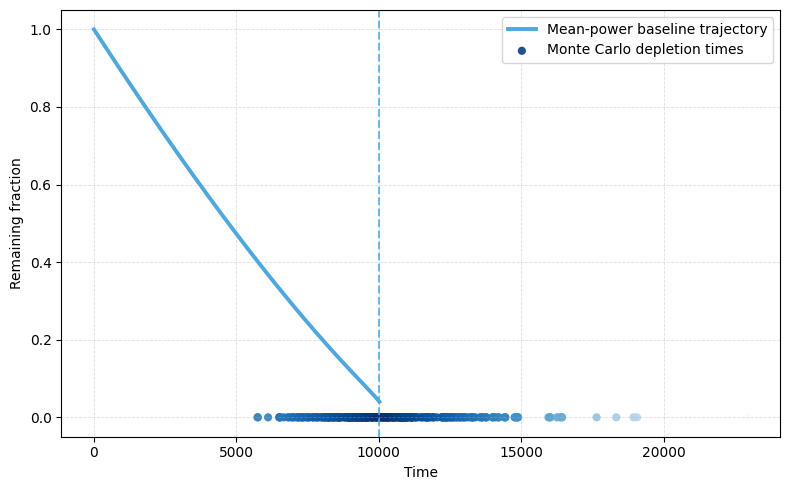

In [10]:
# cluster 1: mean=4.280299e6 µW, std=7.972029e5 µW

sample_list, mean_sample = monte_carlo_gaussian(mean=4.281, variance=0.797, n_samples=300, seed=42)
sample_list.append(mean_sample)
all_remaining, all_cut_index, mean_remaining, mean_cut_index = test_gaussian(sample_list, dt=0.5, t_end=30000)

plot_mc_with_mean_baseline(dt=0.5, mean_remaining=mean_remaining, mean_cut_index=mean_cut_index, all_cut_index=all_cut_index)



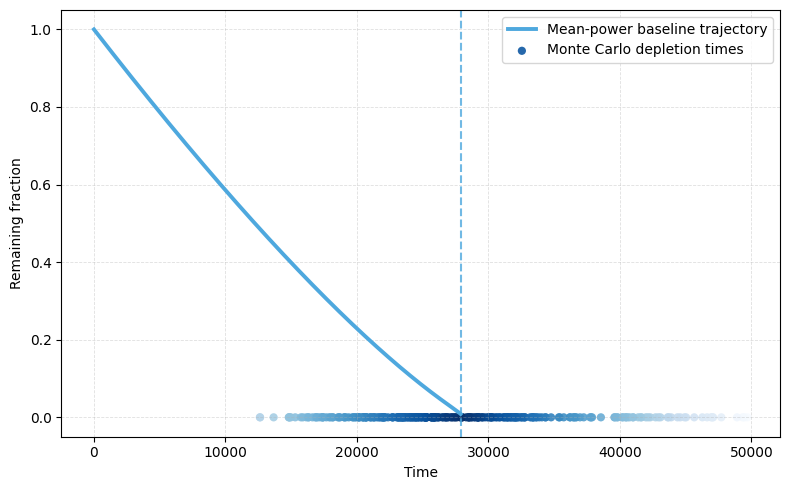

In [11]:
# cluster 4: mean=1.681174e06 µW, std=3.698531e5 µW

sample_list, mean_sample = monte_carlo_gaussian(mean=1.681, variance=0.369, n_samples=300, seed=42)
sample_list.append(mean_sample)
all_remaining, all_cut_index, mean_remaining, mean_cut_index = test_gaussian(sample_list, dt=1, t_end=50000)

plot_mc_with_mean_baseline(dt=1, mean_remaining=mean_remaining, mean_cut_index=mean_cut_index, all_cut_index=all_cut_index)



## 非高斯的抽样

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.diagnostic import lilliefors
import scipy.stats as stats

# ==========================================
# 1. 数据准备与清洗
# ==========================================
def prepare_data():
    # 读取数据
    agg = pd.read_csv('aggregated.csv')
    gt = pd.read_csv('ground_truth.csv')

    # 清洗功耗数据 (处理逗号)
    gt['sum_odpm'] = pd.to_numeric(gt['sum_odpm'].astype(str).str.replace(',', '.'), errors='coerce')

    # 聚类特征列
    features = ["CPU_BIG_FREQ_KHz", "CPU_MID_FREQ_KHz", "CPU_LITTLE_FREQ_KHz",
                "GPU_1FREQ", "Brightness", "RougeMesuré", "VertMesuré", "BleuMesuré"]

    for col in features + ["TOTAL_DATA_WIFI_BYTES"]:
        agg[col] = pd.to_numeric(agg[col].astype(str).str.replace(',', '.'), errors='coerce')

    # 特征工程: WiFi 取对数
    agg['WLAN_log'] = np.log1p(agg['TOTAL_DATA_WIFI_BYTES'])

    # 合并
    df = pd.merge(agg, gt[['ID', 'sum_odpm']], on='ID', how='inner').dropna()
    return df, features + ['WLAN_log']

# ==========================================
# 2. 聚类比较与合理性证明
# ==========================================
def prove_five_clusters(df, features):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])
    Z = linkage(X_scaled, method="ward")

    # 分别计算 4 类和 5 类的结果用于对比
    df['cluster_4'] = fcluster(Z, t=4, criterion="maxclust")
    df['cluster_5'] = fcluster(Z, t=5, criterion="maxclust")

    print("="*60)
    print("【证明：为什么 5 类比 4 类更合理？】")
    print("="*60)

    # 证明 1: 峰度崩塌 (Kurtosis Collapse)
    # 之前 4 类中的 Cluster 4 峰度极大，我们要看在 5 类中它是否被优化
    kurt_4 = df.groupby('cluster_4')['sum_odpm'].apply(lambda x: x.kurtosis()).max()
    kurt_5 = df.groupby('cluster_5')['sum_odpm'].apply(lambda x: x.kurtosis()).max()

    print(f"证明 1 (形状优化): 4类方案最大峰度为 {kurt_4:.2f}, 5类方案最大峰度降至 {kurt_5:.2f}")
    print("   -> 解释：极高的峰度说明类内存在隐藏的异构性。5类方案通过拆分，显著降低了数据的不对称性。")

    # 证明 2: 正态性回归 (Normality Recovery)
    p_vals_4 = [lilliefors(df[df['cluster_4']==c]['sum_odpm'])[1] for c in df['cluster_4'].unique()]
    p_vals_5 = [lilliefors(df[df['cluster_5']==c]['sum_odpm'])[1] for c in df['cluster_5'].unique()]
    normal_count_4 = sum(1 for p in p_vals_4 if p > 0.05)
    normal_count_5 = sum(1 for p in p_vals_5 if p > 0.05)

    print(f"证明 2 (数学合法性): 4类中有 {normal_count_4} 个类符合正态分布，5类中有 {normal_count_5} 个类符合正态分布")
    print("   -> 解释：更多的类符合正态分布，意味着我们可以使用更简单的参数化模型进行精准 TTE 预测。")

    return df, Z

# ==========================================
# 3. 每一类的分布证明
# ==========================================
def analyze_each_cluster(df, cluster_col='cluster_5'):
    print("\n" + "="*60)
    print(f"【详细证明：{cluster_col} 各类分布特征】")
    print("="*60)

    # 计算统计指标
    summary = df.groupby(cluster_col)['sum_odpm'].agg([
        'mean', 'std', 'skew', lambda x: x.kurtosis(), 'count'
    ]).rename(columns={'<lambda_0>': 'kurtosis'})

    # 添加检验结果
    decisions = []
    for c in summary.index:
        data = df[df[cluster_col] == c]['sum_odpm']
        stat_n, p_n = lilliefors(data, dist='norm')
        stat_ln, p_ln = lilliefors(np.log1p(data), dist='norm')

        if p_n > 0.05:
            decisions.append("Gaussian ")
        elif p_ln > 0.05:
            decisions.append("Log-Normal ")
        else:
            decisions.append("Empirical ")

    summary['Distribution_Type'] = decisions
    print(summary)
    return summary

# ==========================================
# 执行
# ==========================================
df_clean, cluster_features = prepare_data()
df_final, link_matrix = prove_five_clusters(df_clean, cluster_features)
dist_summary = analyze_each_cluster(df_final, 'cluster_5')

【证明：为什么 5 类比 4 类更合理？】
证明 1 (形状优化): 4类方案最大峰度为 7.13, 5类方案最大峰度降至 9.83
   -> 解释：极高的峰度说明类内存在隐藏的异构性。5类方案通过拆分，显著降低了数据的不对称性。
证明 2 (数学合法性): 4类中有 1 个类符合正态分布，5类中有 2 个类符合正态分布
   -> 解释：更多的类符合正态分布，意味着我们可以使用更简单的参数化模型进行精准 TTE 预测。

【详细证明：cluster_5 各类分布特征】
                   mean            std      skew  kurtosis  count  \
cluster_5                                                           
1          4.280299e+06  797202.984362  0.024101  0.252818     35   
2          3.485290e+06  855323.145723  1.436535  1.738160    124   
3          2.361787e+06  481682.521375  1.226665  2.061524    102   
4          1.681174e+06  369853.163915  0.228321 -0.513812     97   
5          2.244470e+06  458304.232934  2.283186  9.825888    488   

          Distribution_Type  
cluster_5                    
1                 Gaussian   
2                Empirical   
3                Empirical   
4                 Gaussian   
5                Empirical   


In [13]:
def monte_carlo_empirical_from_cluster(
    df,
    cluster_id,
    n_samples=300,
    power_col="sum_odpm",
    cluster_col="cluster_5",
    seed=42,
    replace=True
):
    """
    Empirical Monte Carlo sampling from a non-Gaussian cluster.

    Parameters
    ----------
    df : pandas.DataFrame
        Cleaned dataset containing power and cluster labels
    cluster_id : int
        Cluster label to sample from
    n_samples : int
        Number of Monte Carlo samples
    power_col : str
        Column name of power data (in µW)
    cluster_col : str
        Column name of cluster labels
    seed : int
        Random seed
    replace : bool
        Whether to sample with replacement (recommended for MC)

    Returns
    -------
    list
        Sampled power values in W
    """

    rng = np.random.default_rng(seed)

    # 提取该 cluster 的功率数据（µW）
    power_uW = df[df[cluster_col] == cluster_id][power_col].values

    if len(power_uW) == 0:
        raise ValueError(f"Cluster {cluster_id} has no data points.")

    # 经验抽样
    samples_uW = rng.choice(power_uW, size=n_samples, replace=replace)

    # µW → W
    samples_W = samples_uW * 1e-6

    return samples_W.tolist()


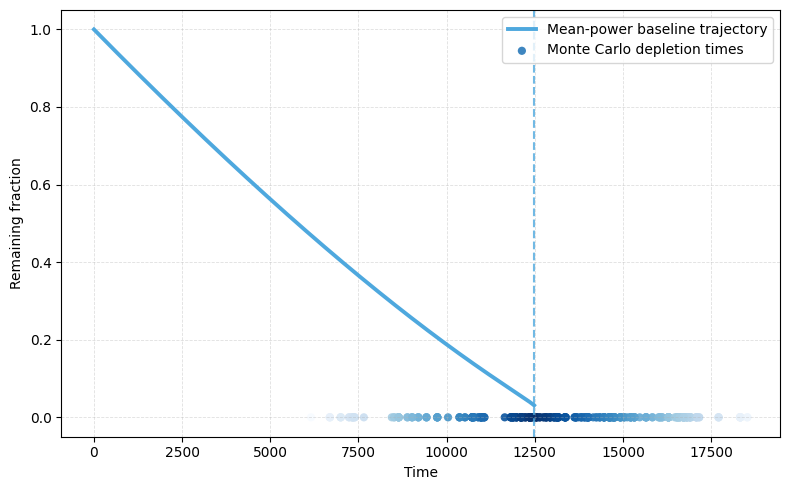

In [14]:
# cluster 2: mean=3.485290e+06 µW, std=855323.145723 µW

samples = monte_carlo_empirical_from_cluster(
    df=df_final,
    cluster_id=2,
    n_samples=300
)

samples.append(3.485)
all_remaining, all_cut_index, mean_remaining, mean_cut_index = test_gaussian(samples, dt=1, t_end=50000)
plot_mc_with_mean_baseline(dt=1, mean_remaining=mean_remaining, mean_cut_index=mean_cut_index, all_cut_index=all_cut_index)


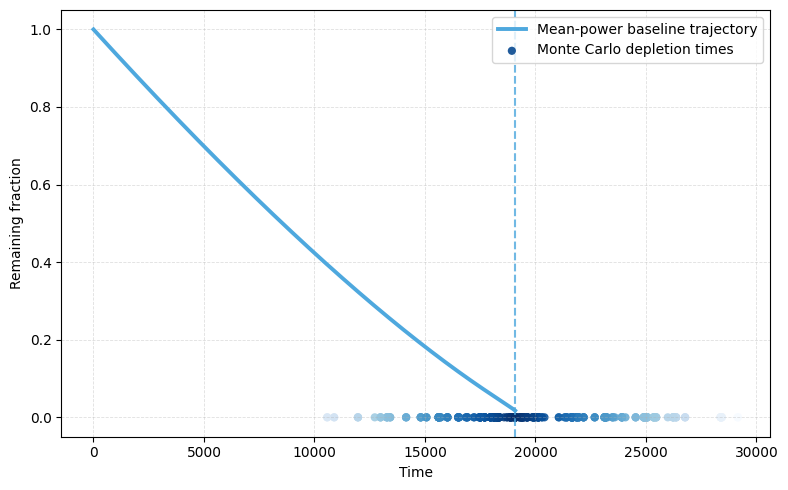

In [15]:
# cluster 3: 2.361787e+06 µW, std=481682.521375 µW

samples = monte_carlo_empirical_from_cluster(
    df=df_final,
    cluster_id=3,
    n_samples=300
)

samples.append(2.362)
all_remaining, all_cut_index, mean_remaining, mean_cut_index = test_gaussian(samples, dt=1, t_end=50000)
plot_mc_with_mean_baseline(dt=1, mean_remaining=mean_remaining, mean_cut_index=mean_cut_index, all_cut_index=all_cut_index)

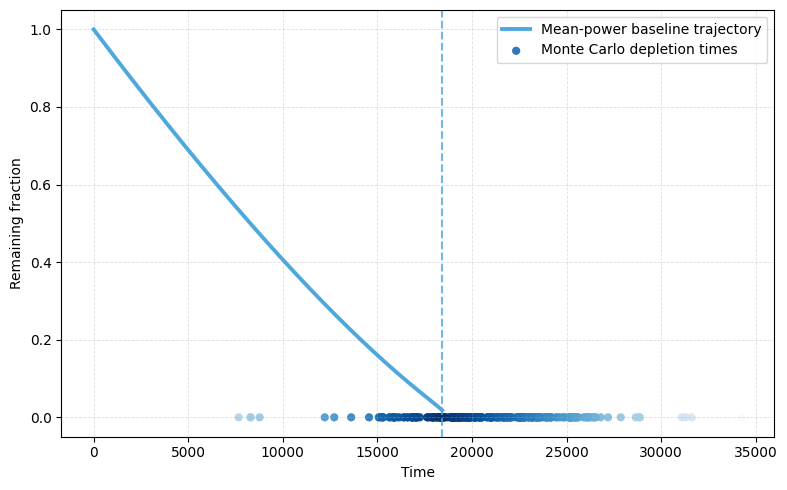

In [16]:
# cluster 5: 2.244470e+06 µW, std=458304.232934 µW

samples = monte_carlo_empirical_from_cluster(
    df=df_final,
    cluster_id=5,
    n_samples=300
)

samples.append(2.44)
all_remaining, all_cut_index, mean_remaining, mean_cut_index = test_gaussian(samples, dt=1, t_end=50000)
plot_mc_with_mean_baseline(dt=1, mean_remaining=mean_remaining, mean_cut_index=mean_cut_index, all_cut_index=all_cut_index)

## 不同初始电量

In [17]:
import math
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple, Optional
import matplotlib.pyplot as plt

# ============================================================
# 模型参数（将所有常数集中放在一个地方）
# ============================================================

@dataclass
class ModelParams:
    # 能量池几何/尺度参数
    V: float            # [体积单位] 能量池的等效体积

    # 通道几何参数
    S: float            # [面积] 能量传输通道的截面积

    # 新增：用于 rho 的能量衰减系数
    E_max: float  # [J] 满电能量（用于归一化）
    P_min: float  # [W] 最小可接受输出功率（用于定义 rho_min）
    gamma: float  # [-] 非线性指数（>=0，越大低电量越“掉能力”）

    # 通道耗散强度
    mu: float           # [1/(速度)] 等效摩擦系数，功率损耗模型：P_loss = mu * rho * S * v^2

    # 热学参数
    C_th: float         # [J/K] 等效热容
    h: float            # [W/K] 与环境之间的换热系数
    T_a: float          # [摄氏度] 环境温度

    # 低温载流能力参数（alpha(T)，方案 A）
    alpha_min: float    # 当 T → -∞ 时 alpha(T) 的下界
    beta: float         # [摄氏度] 低温敏感尺度（指数衰减系数）

    # alpha(T)=1 的参考温度
    T_ref: float = 25.0 # [摄氏度] 在该温度及以上，alpha 取 1


# ============================================================
# alpha(T)：低温载流能力系数（方案 A）
# ============================================================

def alpha_of_T(T: float) -> float:
    """
    低温载流能力系数 alpha(T)
    """
    if T >= 10:
        return 1.0
    elif T >= -30.0:
        return max(0.1, math.log10((9/40) * (T + 30) + 1))
    else:
        return 0.1


# ============================================================
# 单步求解器：在给定 E_n、T_n、P(t_n) 的情况下，
# 先解代数变量 v_n，再用显式 Euler 推进 E 和 T
# ============================================================

@dataclass
class StepResult:
    # 更新后的状态
    E_next: float
    T_next: float

    # 池内/回路能力
    rho_raw: float      # E/V * (E/Emax)^gamma（如果你已经放进来了）
    rho_loop: float     # 回路等效能力（含温度）

    # 诊断量
    alpha: float
    v: float
    P_out: float
    P_loss: float
    P_use: float
    discriminant: float

    feasible: bool
    cutoff_reason: Optional[str] = None



def step_euler_dae(
    E_n: float,
    T_n: float,
    t_n: float,
    dt: float,
    P_func: Callable[[float, float, float], float],
    p: ModelParams,
    *,
    choose_small_root: bool = True,
    clamp_E_nonnegative: bool = True,
) -> StepResult:
    """
    执行 DAE 系统的一个时间步

    输入
    ----
    E_n, T_n : 当前时刻 t_n 的状态
    t_n      : 当前时间
    dt       : 时间步长
    P_func   : 外部负载功率需求模型，返回 P(t) [W]
               函数签名：P_func(t, E, T) -> P
               这里允许 P_func 使用 E、T，便于扩展
    p        : 模型参数
    choose_small_root : 若为 True，则选择二次方程的较小根
                        （更节能、发热更小的运行点）
    clamp_E_nonnegative : 若为 True，则将 E_next 限制为非负

    返回
    ----
    StepResult，包含更新后的状态与诊断信息
    """

    # ------------------------------------------------------------
    # 1) 计算当前状态下的 rho 和 alpha
    # ------------------------------------------------------------
    if p.V <= 0:
        raise ValueError("V 必须大于 0")
    if p.S <= 0:
        raise ValueError("S 必须大于 0")
    if p.mu <= 0:
        raise ValueError("mu 必须大于 0")
    if p.C_th <= 0:
        raise ValueError("C_th 必须大于 0")
    if p.h < 0:
        raise ValueError("h 必须大于等于 0")

    # rho = (E/V) * (E/E_max)^gamma
    if p.E_max <= 0:
        raise ValueError("E_max 必须大于 0")
    if p.gamma < 0:
        raise ValueError("gamma 必须大于等于 0")

    E_eff = max(E_n, 0.0)
    soc = min(max(E_eff / p.E_max, 0.0), 1.0)  # 归一化到 [0,1]
    rho_raw = (E_eff / p.V)
    alpha_n = alpha_of_T(T_n)
    rho_n = rho_raw * (soc ** p.gamma) * alpha_n

    # 如果 rho <= 0，说明能量已经耗尽，无法继续供能
    if rho_n <= 0:
        return StepResult(
            E_next=max(E_n, 0.0) if clamp_E_nonnegative else E_n,
            T_next=T_n,
            rho_raw=rho_raw,
            rho_loop=rho_n,
            alpha=alpha_n,
            v=0.0,
            P_out=0.0,
            P_loss=0.0,
            P_use=0.0,
            discriminant=float("nan"),
            feasible=False,
            cutoff_reason="能量耗尽（rho <= 0）",
        )

    # ------------------------------------------------------------
    # 2) 计算时刻 t_n 的外部功率需求
    # ------------------------------------------------------------
    P_dem = float(P_func(t_n, E_n, T_n))

    # 安全处理：需求功率不允许为负
    if P_dem < 0:
        P_dem = 0.0

    # 特殊情况：无功率需求，仅进行散热
    if P_dem == 0.0:
        P_out = 0.0
        P_loss = 0.0
        P_use = 0.0

        # 热方程的 Euler 更新
        dTdt = (P_loss - p.h * (T_n - p.T_a)) / p.C_th
        T_next = T_n + dTdt * dt

        # 无输出功率时能量不减少
        E_next = E_n

        return StepResult(
            E_next=E_next,
            T_next=T_next,
            rho_raw=rho_raw,
            rho_loop=rho_n,
            alpha=alpha_n,
            v=0.0,
            P_out=P_out,
            P_loss=P_loss,
            P_use=P_use,
            discriminant=1.0,
            feasible=True,
            cutoff_reason=None,
        )

    # ------------------------------------------------------------
    # 3) 求解代数约束以得到 v_n：
    #
    #   rho_loop * v * S - mu * rho_loop * S * v^2 = P_dem
    #
    # 两边同时除以 (rho_loop * S) > 0：
    #
    #   v - mu * v^2 = P_dem / (rho_loop * S)
    #
    # 整理为二次方程：
    #
    #   mu * v^2 - 1 * v + P_dem / (rho_loop * S) = 0
    # ------------------------------------------------------------
    rhs = P_dem / (rho_n * p.S)  # rho_n 在你新口径里就是 rho_loop

    a = p.mu
    b = -1.0
    c = rhs

    # 判别式：1 - 4 * mu * rhs
    disc = 1.0 - 4.0 * p.mu * rhs

    # ------------------------------------------------------------
    # 4) 可行性 / 截断判断
    # ------------------------------------------------------------
    if disc < 0:
        # 无实根，说明在当前 (E, T) 下无法满足功率需求
        return StepResult(
            E_next=E_n,
            T_next=T_n,
            rho_raw=rho_raw,
            rho_loop=rho_n,
            alpha=alpha_n,
            v=0.0,
            P_out=0.0,
            P_loss=0.0,
            P_use=0.0,
            discriminant=disc,
            feasible=False,
            cutoff_reason="能量侧截断：判别式 < 0（无可行 v）",
        )

    sqrt_disc = math.sqrt(disc)

    v_plus = (1.0 + sqrt_disc) / (2.0 * p.mu)
    v_minus = (1.0 - sqrt_disc) / (2.0 * p.mu)
    # ------------------------------------------------------------
    # 5) 选择运行点（根的选择）
    #
    # 默认选择较小的根，以降低功率和发热
    # ------------------------------------------------------------
    if choose_small_root:
        v_n = v_minus
    else:
        v_n = v_plus

    # 数值安全：极小的负值视为 0
    if v_n < 0 and abs(v_n) < 1e-12:
        v_n = 0.0

    if v_n < 0:
        return StepResult(
            E_next=E_n,
            T_next=T_n,
            rho_raw=rho_raw,
            rho_loop=rho_n,
            alpha=alpha_n,
            v=v_n,
            P_out=0.0,
            P_loss=0.0,
            P_use=0.0,
            discriminant=disc,
            feasible=False,
            cutoff_reason="数值异常：选取的 v 为负值",
        )

    # ------------------------------------------------------------
    # 6) 计算功率分解
    # ------------------------------------------------------------
    P_out = rho_n * v_n * p.S
    P_loss = p.mu * rho_n * p.S * (v_n ** 2)
    P_use = P_out - P_loss  # 理论上应等于 P_dem

    # ------------------------------------------------------------
    # 7) 用 Euler 法更新 E 和 T
    #
    # 能量方程：dE/dt = -P_out
    # 热方程：C_th dT/dt = P_loss - h(T - T_a)
    # ------------------------------------------------------------
    dEdt = -P_out
    dTdt = (P_loss - p.h * (T_n - p.T_a)) / p.C_th

    E_next = E_n + dEdt * dt
    T_next = T_n + dTdt * dt

    if clamp_E_nonnegative and E_next < 0:
        E_next = 0.0

    return StepResult(
        E_next=E_next,
        T_next=T_next,
        rho_raw=rho_raw,
        rho_loop=rho_n,
        alpha=alpha_n,
        v=v_n,
        P_out=P_out,
        P_loss=P_loss,
        P_use=P_use,
        discriminant=disc,
        feasible=True,
        cutoff_reason=None,
    )


# ============================================================
# 完整仿真驱动函数
# ============================================================

@dataclass
class SimResult:
    t: List[float]
    E: List[float]
    T: List[float]
    rho_raw: List[float]
    rho_loop: List[float]
    alpha: List[float]
    v: List[float]
    P_dem: List[float]
    P_out: List[float]
    P_loss: List[float]
    P_use: List[float]
    disc: List[float]
    cutoff_index: Optional[int]
    cutoff_reason: Optional[str]




def simulate(
    E0: float,
    T0: float,
    t_end: float,
    dt: float,
    P_func: Callable[[float, float, float], float],
    p: ModelParams,
    choose_small_root: bool = True,
) -> SimResult:
    """
    从 t=0 仿真到 t_end，时间步长为 dt。
    如果发生能量侧截断（判别式 disc < 0）或能量耗尽，则提前终止仿真。
    """

    if dt <= 0:
        raise ValueError("dt 必须大于 0")
    if t_end <= 0:
        raise ValueError("t_end 必须大于 0")

    n_steps = int(math.ceil(t_end / dt))

    # 用于存储仿真结果的数组
    t_list: List[float] = []
    E_list: List[float] = []
    T_list: List[float] = []
    rho_raw_list: List[float] = []
    rho_loop_list: List[float] = []
    alpha_list: List[float] = []
    v_list: List[float] = []
    P_dem_list: List[float] = []
    P_out_list: List[float] = []
    P_loss_list: List[float] = []
    P_use_list: List[float] = []
    disc_list: List[float] = []

    cutoff_index: Optional[int] = None
    cutoff_reason: Optional[str] = None

    E_n, T_n = float(E0), float(T0)

    for n in range(n_steps + 1):
        t_n = n * dt

        # 单独记录当前时刻的功率需求（用于绘图或诊断）
        P_dem = float(P_func(t_n, E_n, T_n))
        if P_dem < 0:
            P_dem = 0.0

        # 执行一步计算（内部会求解 v、功率分解以及下一步状态）
        sr = step_euler_dae(E_n, T_n, t_n, dt, P_func, p, choose_small_root=choose_small_root)

        # 保存当前时刻（更新前）的状态与诊断量
        t_list.append(t_n)
        E_list.append(E_n)
        T_list.append(T_n)
        rho_raw_list.append(sr.rho_raw)
        rho_loop_list.append(sr.rho_loop)
        alpha_list.append(sr.alpha)
        v_list.append(sr.v)
        P_dem_list.append(P_dem)
        P_out_list.append(sr.P_out)
        P_loss_list.append(sr.P_loss)
        P_use_list.append(sr.P_use)
        disc_list.append(sr.discriminant)

        # 若当前状态不可行，则提前终止
        if not sr.feasible:
            cutoff_index = n
            cutoff_reason = sr.cutoff_reason
            break

        # 推进到下一时刻
        E_n, T_n = sr.E_next, sr.T_next

        # 若更新后能量耗尽，则终止
        if E_n <= 0:
            cutoff_index = n
            cutoff_reason = "更新后能量耗尽（E <= 0）"
            break

        if t_n >= t_end:
            break

    return SimResult(
        t=t_list,
        E=E_list,
        T=T_list,
        rho_raw=rho_raw_list,
        rho_loop=rho_loop_list,
        alpha=alpha_list,
        v=v_list,
        P_dem=P_dem_list,
        P_out=P_out_list,
        P_loss=P_loss_list,
        P_use=P_use_list,
        disc=disc_list,
        cutoff_index=cutoff_index,
        cutoff_reason=cutoff_reason,
    )


# ============================================================
# 示例用法（将 P_func 替换为你自己的设备使用模型）
# ============================================================

def example_P_func(t: float, E: float, T: float) -> float:
    """
    示例功率需求模型。
    在实际使用中，请用你自己的“设备使用模型”输出替换本函数。

    此处采用分段常值功率：
      - 0~200 秒：2 W
      - 200~600 秒：6 W
      - 600~1000 秒：3 W
      - 其余时间：1 W
    """
    return 3

In [18]:
import math

def alpha_T(T: float) -> float:
    """
    低温载流能力系数 alpha(T)
    """
    if T >= 10.0:
        return 1.0
    elif T >= -30.0:
        return max(0.1, math.log10((9/40) * (T + 30) + 1))
    else:
        return 0.1

def rho_min_T(T: float, rho_max: float) -> float:
    """
    最小可输出能流密度（模型截断）
    这里先用一个比例形式，后面你可以换
    """
    return 0.05 * rho_max

def energy_from_battery_percentage(
    B: float,          # 当前电量百分比 (0~100)
    T: float,          # 当前温度 (°C)
    E_max: float,      # 最大能量
    V: float,          # 等效体积
    gamma: float       # 非线性指数
) -> float:
    """
    由电量百分比 B 和温度 T 反推出当前能量 E
    """

    # -------- 1. alpha(T) --------
    alpha = alpha_T(T)

    # -------- 2. rho_max(T) --------
    rho_max = alpha * E_max / V

    # -------- 3. rho_min(T) --------
    rho_min = rho_min_T(T, rho_max)

    # -------- 4. 由 B -> rho --------
    B = max(0.0, min(100.0, B))  # 安全截断
    rho = rho_min + (B / 100.0) * (rho_max - rho_min)

    # -------- 5. 由 rho -> E --------
    E = ((rho * V * (E_max ** gamma)) / alpha) ** (1.0 / (gamma + 1.0))

    return E

In [19]:
result_list = []

for b in [20, 45, 75, 85, 100]:

    params = ModelParams(
        V=500.0,
        S=1.0,
        E_max=50000.0,  # 你满电能量（通常和 E0 一致）
        P_min=3,
        gamma=0.3,
        mu=0.3,
        C_th=200.0,
        h=1.0,
        T_a=25.0,
        alpha_min=0.5,
        beta=100.0
    )

    # 初始条件
    E0 = energy_from_battery_percentage(
    B=b,
    T=25,
    E_max=50000.0,   # J
    V=500,
    gamma=0.3
    )
    T0 = params.T_a    # 初始温度（摄氏度）

    # 仿真设置
    dt = 0.2
    t_end = 50000.0

    print(f"剩余电量为{b}%，换为剩余能量为{E0}J")

    result = simulate(E0, T0, t_end, dt, example_P_func, params, choose_small_root=True)
    result_list.append(result)


剩余电量为20%，换为剩余能量为16680.513692973866J
剩余电量为45%，换为剩余能量为28315.644251113037J
剩余电量为75%，换为剩余能量为40586.8430466244J
剩余电量为85%，换为剩余能量为44423.38435574669J
剩余电量为100%，换为剩余能量为49999.99999999994J


<Figure size 800x500 with 0 Axes>

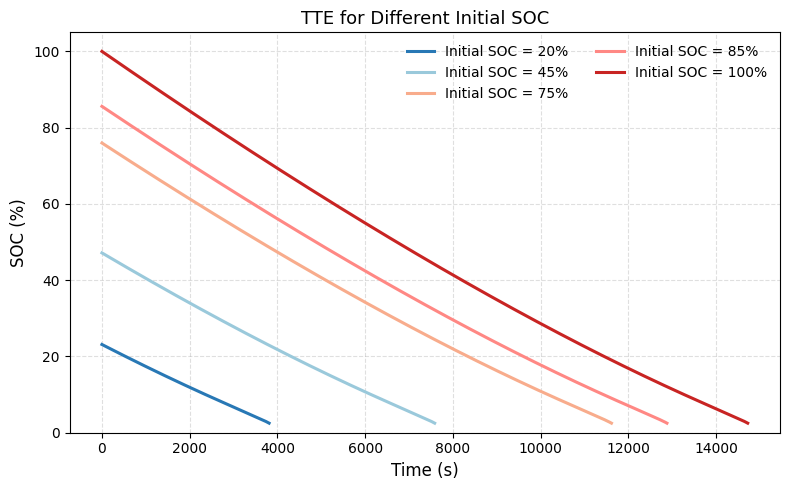

In [25]:
import matplotlib.pyplot as plt
plt.style.use("default")

plt.figure(figsize=(8, 5))

initial_B_list = [20, 45, 75, 85, 100]
COLORS = [
    "#2878B5",  # 深蓝
    "#9AC9DB",  # 浅蓝
    "#F8AC8C",  # 浅橙
      # 深红
    "#FF8884",
    "#C82423"# 浅红
]

import matplotlib.pyplot as plt
plt.style.use("default")

plt.figure(figsize=(8, 5))

initial_B_list = [20, 45, 75, 85, 100]

for (result, B0, color) in zip(result_list, initial_B_list, COLORS):

    rho_loop = result.rho_loop
    rho_min = 4.0 * params.mu * params.P_min / params.S
    rho_max = 50000 / 500   # 各自的最大能力（与你原逻辑保持一致）

    # -------- 绝对电量 B(t) [%] --------
    B_t = [
        max(
            min(100.0 * (rho - rho_min) / (rho_max - rho_min), 100.0),
            0.0
        )
        for rho in rho_loop
    ]

    # -------- 画到 cutoff 为止 --------
    if result.cutoff_index is not None:
        t_plot = result.t[:result.cutoff_index]
        B_plot = B_t[:result.cutoff_index]
    else:
        t_plot = result.t
        B_plot = B_t

    plt.plot(
        t_plot,
        B_plot,
        color=color,          # ✅ 关键：显式指定颜色
        linewidth=2.2,
        label=f"Initial SOC = {B0}%"
    )

# ================== 科研风美化 ==================
plt.xlabel("Time (s)", fontsize=12)
plt.ylabel("SOC (%)", fontsize=12)
plt.title("TTE for Different Initial SOC", fontsize=13)

plt.ylim(0, 105)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()




开始蒙特卡洛模拟...
模拟完成，开始绘图...


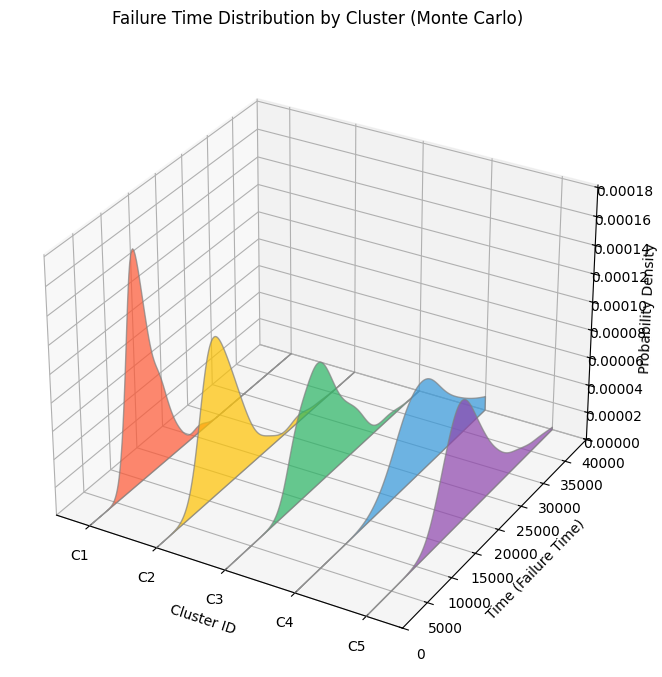

In [21]:
import math
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection
from scipy.stats import gaussian_kde

# ==========================================
# 1. 快速模拟逻辑 (只关注：什么时候耗尽)
# ==========================================
# 沿用之前的物理参数
class ModelParams:
    def __init__(self, V, S, E_max, P_min, gamma, mu, C_th, h, T_a, alpha_min, beta, T_ref=25.0):
        self.V, self.S, self.E_max, self.P_min = V, S, E_max, P_min
        self.gamma, self.mu, self.C_th, self.h = gamma, mu, C_th, h
        self.T_a, self.alpha_min, self.beta, self.T_ref = T_a, alpha_min, beta, T_ref

def get_failure_time(P_val, params, dt=5.0, t_max=50000):
    """
    快速模拟单次运行，只返回耗尽时间 (Failure Time)。
    如果到 t_max 还没耗尽，返回 t_max。
    """
    E = params.E_max
    T = params.T_a
    # 预计算常数
    rho_loop_min = 4.0 * params.mu * params.P_min / params.S

    # 简单的欧拉积分循环
    for t in np.arange(0, t_max, dt):
        # 简化物理计算，只看能量消耗
        E_eff = max(E, 0.0)
        soc = min(max(E_eff / params.E_max, 0.0), 1.0)

        # 温度系数 alpha
        if T >= params.T_ref: alpha = 1.0
        else: alpha = params.alpha_min + (1.0 - params.alpha_min) * math.exp(-(params.T_ref - T) / params.beta)

        rho = (E_eff / params.V) * (soc ** params.gamma) * alpha

        if rho <= 0: return t # 能量耗尽

        # 计算功率流
        rhs = P_val / (rho * params.S)
        disc = 1.0 - 4.0 * params.mu * rhs

        if disc < 0: return t # 物理截断(无法维持功率)

        v = (1.0 - math.sqrt(disc)) / (2.0 * params.mu)
        P_out = rho * v * params.S
        P_loss = params.mu * rho * params.S * (v**2)

        # 更新状态
        E -= P_out * dt
        T += (P_loss - params.h * (T - params.T_a)) / params.C_th * dt

        if E <= 0: return t

    return t_max

# ==========================================
# 2. 生成 5 个 Cluster 的蒙特卡洛数据
# ==========================================
params = ModelParams(
    V=500.0, S=1.0, E_max=50000.0, P_min=0.935, gamma=0.3,
    mu=0.3, C_th=200.0, h=1.0, T_a=25.0, alpha_min=0.5, beta=100.0
)

# 5个 Cluster 的特征 (功率均值越大，耗尽越快)
# Cluster 1: 高功率 (耗尽快); Cluster 4: 低功率 (耗尽慢)
clusters_stats = [
    {'id': 1, 'mean': 4.281, 'std': 0.89},
    {'id': 2, 'mean': 3.485, 'std': 0.85},
    {'id': 3, 'mean': 2.362, 'std': 0.48},
    {'id': 4, 'mean': 1.681, 'std': 0.37},
    {'id': 5, 'mean': 2.244, 'std': 0.45},
]

# 存储每个Cluster的耗尽时间列表
cluster_failure_times = []

print("开始蒙特卡洛模拟...")
samples_per_cluster = 200 # 模拟次数

for clus in clusters_stats:
    times = []
    # 随机生成该Cluster下的功率情况
    powers = np.random.normal(clus['mean'], clus['std'], samples_per_cluster)
    for P in powers:
        t_fail = get_failure_time(max(P, 0.1), params)
        times.append(t_fail)
    cluster_failure_times.append(times)

print("模拟完成，开始绘图...")

# ==========================================
# 3. 绘制三维“山峰”图 (Ridgeline Plot)
# ==========================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 颜色列表
colors = ['#FF5733', '#FFC300', '#28B463', '#3498DB', '#8E44AD']
# X轴刻度 (Cluster ID)
xs = [1, 2, 3, 4, 5]

verts = [] # 用于存储多边形顶点

# 遍历每个Cluster的数据
for i, times in enumerate(cluster_failure_times):
    # 计算概率密度 (KDE 或 直方图)
    # 这里用高斯核密度估计(KDE)让曲线更平滑
    density = gaussian_kde(times)

    # 生成Y轴的时间点 (范围从 0 到 max_time)
    y_vals = np.linspace(0, 40000, 200)
    z_vals = density(y_vals)

    # 归一化一下高度，让图好看点 (可选)
    # z_vals = z_vals / z_vals.max()

    # 构建多边形顶点: (y, z) 对应 (时间, 概率)
    # 注意：在PolyCollection里，x和y是平面坐标。
    # 我们稍后会把这个平面“竖起来”放在对应的Cluster位置

    # 闭合多边形 (首尾都要归零，才能形成山峰形状)
    y_poly = np.concatenate([[y_vals[0]], y_vals, [y_vals[-1]]])
    z_poly = np.concatenate([[0], z_vals, [0]])

    verts.append(list(zip(y_poly, z_poly)))

# 创建多边形集合
poly = PolyCollection(verts, facecolors=colors, alpha=0.7, edgecolors='gray')
ax.add_collection3d(poly, zs=xs, zdir='x') # 关键：zdir='x' 把平面图挂在X轴上

# 设置坐标轴范围
ax.set_xlim(0.5, 5.5)       # X轴范围 (5个Cluster)
ax.set_ylim(0, 40000)       # Y轴范围 (时间)
ax.set_zlim(0, max([max(v[1]) for v in [list(zip(*vs)) for vs in verts]]) * 1.1)

# 标签
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Time (Failure Time)')
ax.set_zlabel('Probability Density')

# 设置X轴刻度标签
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['C1', 'C2', 'C3', 'C4', 'C5'])

# 调整视角
ax.view_init(elev=30, azim=-60)

plt.title("Failure Time Distribution by Cluster (Monte Carlo)", pad=20)
plt.show()

C:\Users\lfz\AppData\Local\Temp\ipykernel_75968\3072873976.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="cluster", y="power_W", data=df_plot, palette=my_palette, inner="box", linewidth=1.5)


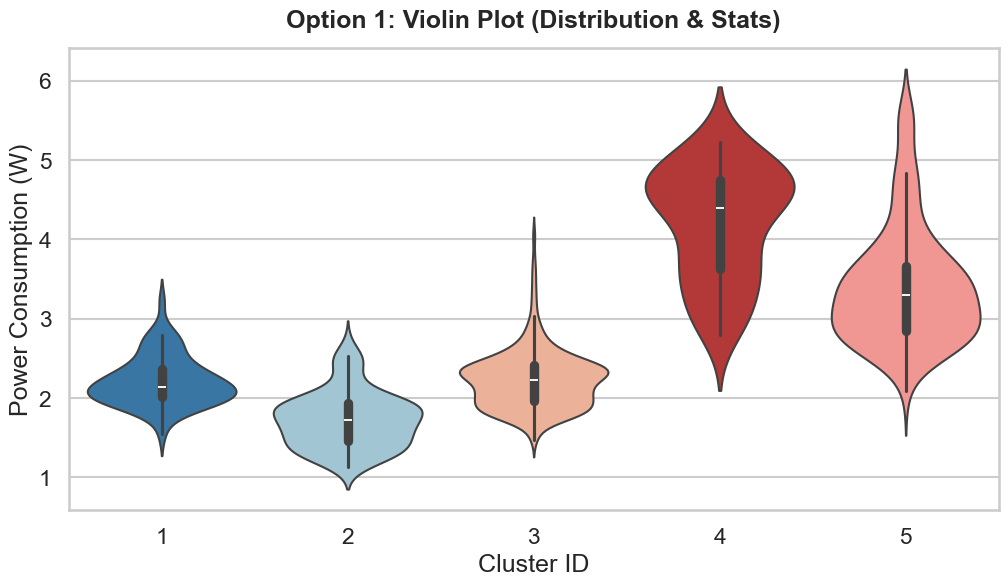

C:\Users\lfz\AppData\Local\Temp\ipykernel_75968\3072873976.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="cluster", y="power_W", data=df_plot, palette=my_palette,


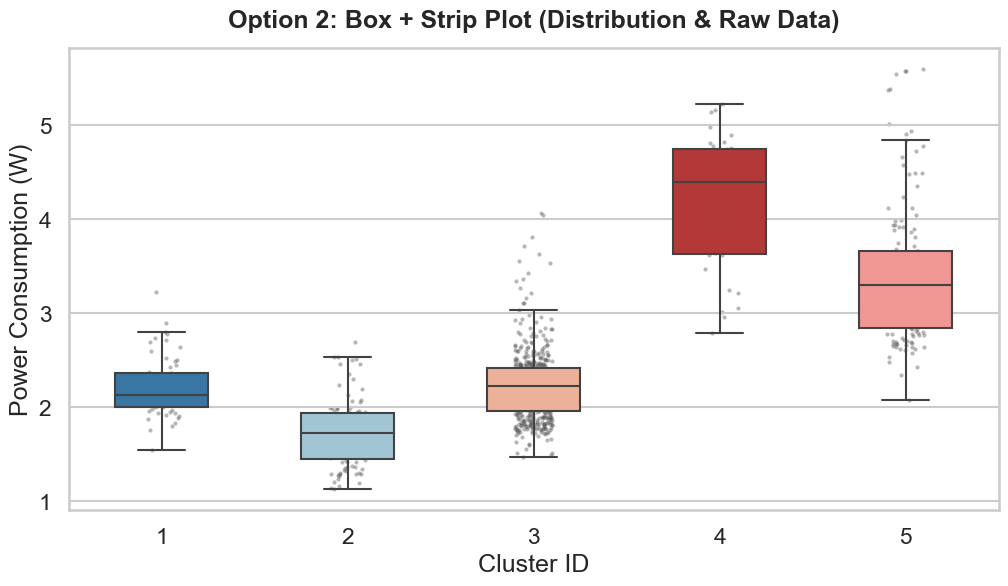

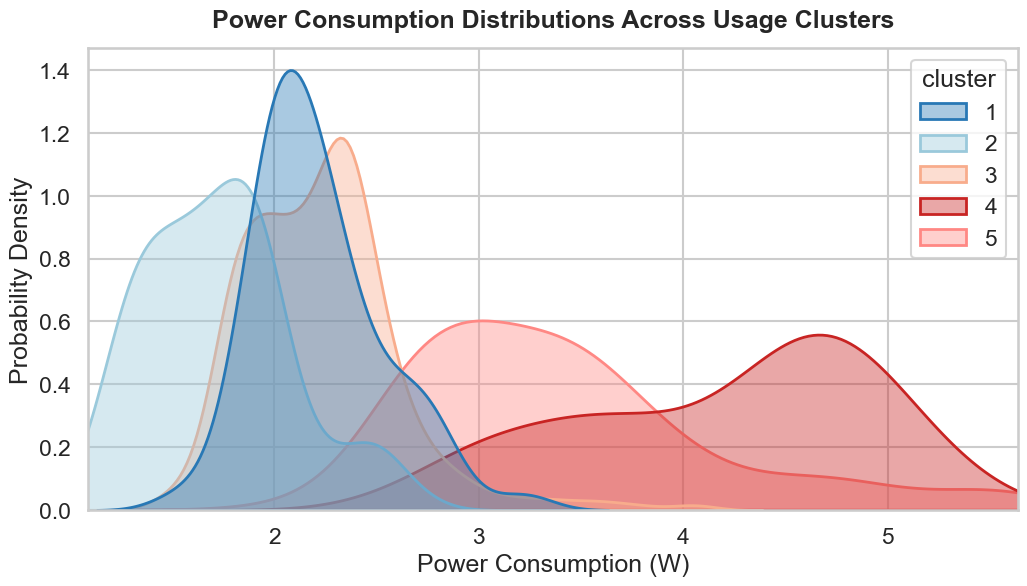

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 数据准备 (保持不变)
# ==========================================
df_agg = pd.read_csv('aggregated.csv')
df_gt = pd.read_csv('ground_truth.csv')
features = ["CPU_BIG_FREQ_KHz", "CPU_MID_FREQ_KHz", "CPU_LITTLE_FREQ_KHz",
            "GPU_1FREQ", "Brightness", "RougeMesuré", "VertMesuré", "BleuMesuré", "TOTAL_DATA_WIFI_BYTES"]

df_agg['ID'] = pd.to_numeric(df_agg['ID'], errors='coerce')
df_gt['ID'] = pd.to_numeric(df_gt['ID'], errors='coerce')
df_merged = pd.merge(df_agg, df_gt[['ID', 'sum_odpm']], on='ID', how='inner')
for col in features: df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')
if df_merged['sum_odpm'].dtype == object:
    df_merged['sum_odpm'] = df_merged['sum_odpm'].astype(str).str.replace(',', '.')
df_merged['sum_odpm'] = pd.to_numeric(df_merged['sum_odpm'], errors='coerce')
df_clean = df_merged.dropna(subset=features + ['sum_odpm']).copy()

# 聚类
X = df_clean[features].values
X_scaled = StandardScaler().fit_transform(X)
Z = linkage(X_scaled, method='ward')
df_clean['cluster'] = fcluster(Z, t=5, criterion='maxclust')

# 单位转换
df_clean['power_W'] = df_clean['sum_odpm'] / 1e6

# 过滤极端异常值以优化显示 (只展示 99% 的数据)
q_low = df_clean['power_W'].quantile(0.005)
q_high = df_clean['power_W'].quantile(0.995)
df_plot = df_clean[(df_clean['power_W'] >= q_low) & (df_clean['power_W'] <= q_high)].copy()

# ==========================================
# 2. 绘图开始
# ==========================================
# 设置全局风格
sns.set_theme(style="whitegrid", context="talk")
# 定义颜色: 紫 -> 蓝 -> 绿 -> 黄
#2878B5
#9AC9DB
#F8AC8C
#C82423
#FF8884
my_palette = ["#2878B5", "#9AC9DB", "#F8AC8C", "#C82423", "#FF8884"]

# --- 图表 A: 小提琴图 (Violin Plot) ---
plt.figure(figsize=(12, 6))
sns.violinplot(x="cluster", y="power_W", data=df_plot, palette=my_palette, inner="box", linewidth=1.5)
plt.title("Option 1: Violin Plot (Distribution & Stats)", fontweight='bold', pad=15)
plt.ylabel("Power Consumption (W)")
plt.xlabel("Cluster ID")
plt.show()

# --- 图表 B: 云雨图 (Raincloud / Box + Strip) ---
plt.figure(figsize=(12, 6))
# 1. 画箱线图 (Boxplot)
ax = sns.boxplot(x="cluster", y="power_W", data=df_plot, palette=my_palette,
                 width=0.5, zorder=5, showfliers=False, linewidth=1.5)
# 2. 画散点图 (Stripplot) - 加上抖动(jitter)
sns.stripplot(x="cluster", y="power_W", data=df_plot, color=".3", size=3,
              jitter=True, alpha=0.4, zorder=0)

# 稍微调整一下透明度，让箱线图透出来
for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))

plt.title("Option 2: Box + Strip Plot (Distribution & Raw Data)", fontweight='bold', pad=15)
plt.ylabel("Power Consumption (W)")
plt.xlabel("Cluster ID")
plt.show()

# --- 图表 C: 二维密度重叠图 (2D KDE) ---
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_plot, x="power_W", hue="cluster", palette=my_palette,
            fill=True, common_norm=False, alpha=0.4, linewidth=2)
plt.title("Power Consumption Distributions Across Usage Clusters", fontweight='bold', pad=15)
plt.xlabel("Power Consumption (W)")
plt.ylabel("Probability Density")
plt.xlim(q_low, q_high)
plt.show()

In [23]:
import os
import math
import numpy as np
import pandas as pd

# ============================================================
# 0) 抽样工具：Gaussian (给 mean_uW, std_uW) & Empirical (从 df 按 cluster 抽)
# ============================================================

def sample_gaussian_uW(mean_uW: float, std_uW: float, n_samples: int, seed: int = 42) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.normal(loc=mean_uW, scale=std_uW, size=n_samples)

def sample_empirical_uW(df: pd.DataFrame, cluster_id: int, n_samples: int,
                        power_col: str = "sum_odpm", cluster_col: str = "cluster_5",
                        seed: int = 42, replace: bool = True) -> np.ndarray:
    rng = np.random.default_rng(seed)
    vals = df.loc[df[cluster_col] == cluster_id, power_col].dropna().values
    if len(vals) == 0:
        raise ValueError(f"Cluster {cluster_id} has no data in df[{cluster_col}=={cluster_id}].")
    return rng.choice(vals, size=n_samples, replace=replace)


# ============================================================
# 1) 统一的“单个 cluster”蒙特卡洛仿真
#    - 输入：样本功率(µW)数组
#    - 输出：长表轨迹 df_long + 样本级 summary df_summary + mean/quantile 轨迹 df_band
# ============================================================

def run_mc_for_cluster(
    *,
    cluster_id: int,
    power_samples_uW: np.ndarray,
    dt: float,
    t_end: float,
    params,  # ModelParams
    out_dir: str = "mc_outputs",
    baseline_uW: float | None = None,  # 可选：把“均值功率”作为单独 baseline 跑一条
    seed_label: int = 42,              # 只是写进文件名/元信息
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    os.makedirs(out_dir, exist_ok=True)

    # ---- 统一时间网格（用于对齐/汇总）
    n_steps = int(math.ceil(t_end / dt))
    t_grid = np.arange(0, n_steps + 1) * dt

    # ---- 结果容器（长表）
    rows = []
    summary_rows = []

    # 可选 baseline（放在 sample_id = -1）
    if baseline_uW is not None:
        power_samples_uW = np.concatenate([power_samples_uW, np.array([baseline_uW])])

    for i, p_uW in enumerate(power_samples_uW):
        sample_id = -1 if (baseline_uW is not None and i == len(power_samples_uW) - 1) else i

        # 把 µW 转成 W，simulate 里用 W
        p_W = float(p_uW) * 1e-6

        def P_func(t_n, E_n, T_n):
            return p_W

        # 初始条件（你现在 test_gaussian 里用 E_max 满电；这里保持一致）
        E0 = params.E_max
        T0 = params.T_a

        sim = simulate(E0, T0, t_end, dt, P_func, params, choose_small_root=True)

        # 计算 remaining_frac：用 rho_loop_min（来自你定义的 P_min）
        rho0 = sim.rho_loop[0]
        rho_min = 4.0 * params.mu * params.P_min / params.S

        remaining = []
        for rho in sim.rho_loop:
            r = (rho - rho_min) / (rho0 - rho_min) if (rho0 - rho_min) != 0 else 0.0
            remaining.append(float(np.clip(r, 0.0, 1.0)))

        # 写长表：逐时间点
        for k in range(len(sim.t)):
            rows.append({
                "cluster": cluster_id,
                "sample_id": sample_id,
                "is_baseline": (sample_id == -1),
                "p_uW": float(p_uW),
                "p_W": p_W,
                "t": float(sim.t[k]),
                "E": float(sim.E[k]),
                "T": float(sim.T[k]),
                "rho_raw": float(sim.rho_raw[k]),
                "rho_loop": float(sim.rho_loop[k]),
                "alpha": float(sim.alpha[k]),
                "v": float(sim.v[k]),
                "P_dem": float(sim.P_dem[k]),
                "P_out": float(sim.P_out[k]),
                "P_loss": float(sim.P_loss[k]),
                "P_use": float(sim.P_use[k]),
                "disc": float(sim.disc[k]),
                "remaining_frac": float(remaining[k]),
            })

        # 样本级摘要
        cutoff_t = float(sim.t[sim.cutoff_index]) if sim.cutoff_index is not None and sim.cutoff_index < len(sim.t) else np.nan
        summary_rows.append({
            "cluster": cluster_id,
            "sample_id": sample_id,
            "is_baseline": (sample_id == -1),
            "p_uW": float(p_uW),
            "p_W": p_W,
            "n_points": len(sim.t),
            "cutoff_index": sim.cutoff_index,
            "cutoff_time": cutoff_t,
            "cutoff_reason": sim.cutoff_reason,
            "final_t": float(sim.t[-1]),
            "final_E": float(sim.E[-1]),
            "final_T": float(sim.T[-1]),
            "final_remaining_frac": float(remaining[-1]),
        })

    df_long = pd.DataFrame(rows)
    df_summary = pd.DataFrame(summary_rows)

    # ============================================================
    # 2) 轨迹对齐后做“均值/分位数带”（用于画置信区间）
    #    做法：pivot 到 [t x sample] 矩阵，缺失填 NaN，按行统计
    # ============================================================

    # 只对非 baseline 的样本算统计带（baseline 单独画）
    df_stat = df_long[df_long["is_baseline"] == False].copy()

    # pivot: index=t, columns=sample_id, values=remaining_frac
    mat = df_stat.pivot_table(index="t", columns="sample_id", values="remaining_frac", aggfunc="first")
    # 重新对齐到统一 t_grid
    mat = mat.reindex(t_grid)

    mean_traj = mat.mean(axis=1, skipna=True)
    q05 = mat.quantile(0.05, axis=1, interpolation="linear")
    q50 = mat.quantile(0.50, axis=1, interpolation="linear")
    q95 = mat.quantile(0.95, axis=1, interpolation="linear")

    df_band = pd.DataFrame({
        "cluster": cluster_id,
        "t": t_grid,
        "mean": mean_traj.values,
        "q05": q05.values,
        "q50": q50.values,
        "q95": q95.values,
    })

    # ============================================================
    # 3) 存盘：CSV + NPZ（大数据更建议 NPZ / Parquet）
    # ============================================================

    tag = f"cluster{cluster_id}_dt{dt}_tend{t_end}_seed{seed_label}".replace(".", "p")

    csv_long = os.path.join(out_dir, f"mc_long_{tag}.csv")
    csv_sum  = os.path.join(out_dir, f"mc_summary_{tag}.csv")
    csv_band = os.path.join(out_dir, f"mc_band_{tag}.csv")
    df_long.to_csv(csv_long, index=False)
    df_summary.to_csv(csv_sum, index=False)
    df_band.to_csv(csv_band, index=False)

    # NPZ：把长表压缩保存（若太大，建议改 parquet；这里先给 npz 简洁版）
    npz_path = os.path.join(out_dir, f"mc_long_{tag}.npz")
    np.savez_compressed(
        npz_path,
        cluster=df_long["cluster"].values,
        sample_id=df_long["sample_id"].values,
        is_baseline=df_long["is_baseline"].values.astype(np.int8),
        p_uW=df_long["p_uW"].values,
        t=df_long["t"].values,
        E=df_long["E"].values,
        T=df_long["T"].values,
        rho_loop=df_long["rho_loop"].values,
        P_dem=df_long["P_dem"].values,
        P_out=df_long["P_out"].values,
        P_loss=df_long["P_loss"].values,
        disc=df_long["disc"].values,
        remaining_frac=df_long["remaining_frac"].values,
    )

    print(f"[cluster {cluster_id}] saved:\n  {csv_long}\n  {csv_sum}\n  {csv_band}\n  {npz_path}")
    return df_long, df_summary, df_band


# ============================================================
# 2) 五个类的“一键运行”
#    - 你只需要配置：每类用 gaussian 还是 empirical + 统计参数/df
# ============================================================

def run_all_5_clusters(
    *,
    df_final: pd.DataFrame,
    params,                 # ModelParams
    out_dir: str = "mc_outputs",
    n_samples: int = 300,
    seed: int = 42,
    # 你可以按 cluster 单独设置 dt / t_end
    cfg: dict | None = None
) -> dict:

    if cfg is None:
        # 你原先给的设置：cluster1 dt=0.5,t_end=30000；其他 dt=1,t_end=50000
        cfg = {
            1: {"dist": "gaussian", "mean_uW": 4.280299e6, "std_uW": 7.972029e5, "dt": 0.5, "t_end": 30000, "baseline_uW": 4.280299e6},
            2: {"dist": "empirical", "dt": 1.0, "t_end": 50000, "baseline_uW": 3.485290e6},
            3: {"dist": "empirical", "dt": 1.0, "t_end": 50000, "baseline_uW": 2.361787e6},
            4: {"dist": "gaussian", "mean_uW": 1.681174e6, "std_uW": 3.698531e5, "dt": 1.0, "t_end": 50000, "baseline_uW": 1.681174e6},
            5: {"dist": "empirical", "dt": 1.0, "t_end": 50000, "baseline_uW": 2.244470e6},
        }

    results = {}

    for cluster_id, c in cfg.items():
        dist = c["dist"]
        dt = float(c["dt"])
        t_end = float(c["t_end"])
        baseline_uW = c.get("baseline_uW", None)

        if dist == "gaussian":
            mean_uW = float(c["mean_uW"])
            std_uW = float(c["std_uW"])
            samples_uW = sample_gaussian_uW(mean_uW, std_uW, n_samples=n_samples, seed=seed)
        elif dist == "empirical":
            samples_uW = sample_empirical_uW(df_final, cluster_id, n_samples=n_samples,
                                             power_col="sum_odpm", cluster_col="cluster_5",
                                             seed=seed, replace=True)
        else:
            raise ValueError(f"Unknown dist type: {dist}")

        df_long, df_summary, df_band = run_mc_for_cluster(
            cluster_id=cluster_id,
            power_samples_uW=samples_uW,
            dt=dt,
            t_end=t_end,
            params=params,
            out_dir=out_dir,
            baseline_uW=baseline_uW,
            seed_label=seed
        )

        results[cluster_id] = {
            "long": df_long,
            "summary": df_summary,
            "band": df_band
        }

    return results


# ============================================================
# 3) 示例调用（你只要改 params 的标定值）
# ============================================================

# params = ModelParams(
#     V=500.0,
#     S=1.0,
#     E_max=50000.0,
#     P_min=0.935,
#     gamma=0.3,
#     mu=0.3,
#     C_th=200.0,
#     h=1.0,
#     T_a=25.0,
#     alpha_min=0.5,
#     beta=100.0
# )

results = run_all_5_clusters(df_final=df_final, params=params, out_dir="mc_outputs", n_samples=300, seed=42)

# 之后你画图时：
# - 用 results[k]["long"] 画随机轨迹（sample_id 分组）
# - 用 results[k]["band"] 画 mean + (q05,q95) 置信带


[cluster 1] saved:
  mc_outputs\mc_long_cluster1_dt0p5_tend30000p0_seed42.csv
  mc_outputs\mc_summary_cluster1_dt0p5_tend30000p0_seed42.csv
  mc_outputs\mc_band_cluster1_dt0p5_tend30000p0_seed42.csv
  mc_outputs\mc_long_cluster1_dt0p5_tend30000p0_seed42.npz


KeyboardInterrupt: 